# **Movie Recommender System**

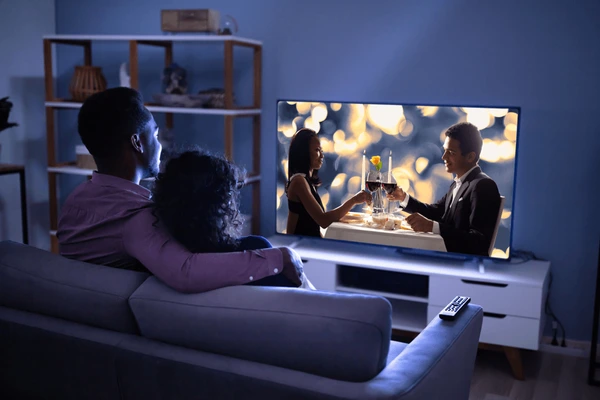




# **Project Details**

A movie recommender system is a type of intelligent algorithm that suggests movies to users based on their past viewing behavior and preferences. These systems analyze data like user ratings, reviews, and viewing histories to generate personalized recommendations, helping users discover new movies more efficiently.

The goal of this project is to build a movie recommendation system using collaborative filtering. We'll focus on user-based collaborative filtering, where recommendations are made based on the preferences of similar users. This method will rely on user ratings and movie features.

# **About the Dataset**

This dataset comprises user-generated movie ratings and metadata for a wide range of films, commonly used for recommender systems research and analysis. It has two files which are:

**1. ratings.csv**

This file contains 100,836 ratings provided by users for different movies. The structure of the file is as follows:

**userId:** A unique identifier for each user.

**movieId:**A unique identifier for each movie (corresponds with movieId in movies.csv).

**rating:** The score (on a scale from 0.5 to 5.0, in 0.5 increments) given by a user to a movie.

timestamp: The time when the rating was given, represented as a Unix timestamp.

**2. movies.csv**

This file contains metadata for 9,742 movies. The columns are:

**movieId:** Unique identifier for each movie (matches with ratings.csv).

**title:** The title of the movie, often including the release year.

**genres:** A pipe-separated list of genres (e.g., Action|Adventure|Comedy), describing the movie's category or categories.

.

**Dataset Reference:** https://www.kaggle.com/datasets/gargmanas/movierecommenderdataset/data


# **Import Required Libraries**

In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics.pairwise import cosine_similarity

# **Data Loading and Overview**

In [7]:
#Load the dataset
movies= pd.read_csv('movies.csv')
ratings=pd.read_csv('ratings.csv')

#View the dataset
print(movies.head())

print(ratings.head())

   movieId                               title  \
0        1                    Toy Story (1995)   
1        2                      Jumanji (1995)   
2        3             Grumpier Old Men (1995)   
3        4            Waiting to Exhale (1995)   
4        5  Father of the Bride Part II (1995)   

                                        genres  
0  Adventure|Animation|Children|Comedy|Fantasy  
1                   Adventure|Children|Fantasy  
2                               Comedy|Romance  
3                         Comedy|Drama|Romance  
4                                       Comedy  
   userId  movieId  rating  timestamp
0       1        1     4.0  964982703
1       1        3     4.0  964981247
2       1        6     4.0  964982224
3       1       47     5.0  964983815
4       1       50     5.0  964982931


In [45]:
# Merge for convenience
data = pd.merge(ratings, movies, on='movieId')

# View
data.head()

,userId,movieId,rating,timestamp,title,genres
0,1,1,4.0,964982703,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,1,3,4.0,964981247,Grumpier Old Men (1995),Comedy|Romance
2,1,6,4.0,964982224,Heat (1995),Action|Crime|Thriller
3,1,47,5.0,964983815,Seven (a.k.a. Se7en) (1995),Mystery|Thriller
4,1,50,5.0,964982931,"Usual Suspects, The (1995)",Crime|Mystery|Thriller


# **Exploratory Data Analysis (EDA)**

In [54]:
movies['title'].value_counts().sum()

np.int64(9742)

In [52]:
data.duplicated().sum()

np.int64(0)

In [55]:
data.isnull().sum()

,0
userId,0
movieId,0
rating,0
timestamp,0
title,0
genres,0


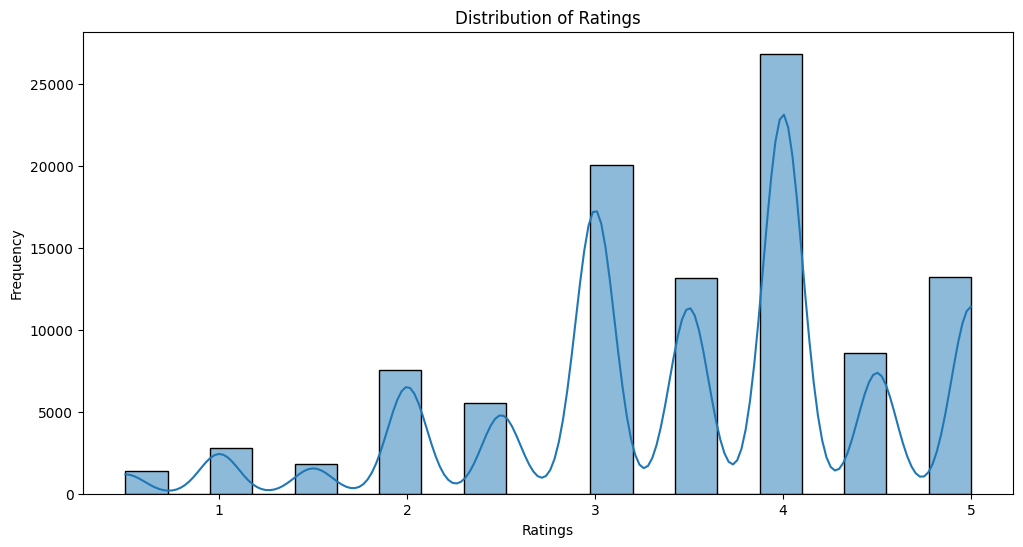

In [57]:
#Plot the distribution of ratings

plt.figure(figsize=(12,6))
sns.histplot(data['rating'],bins=20,kde=True)
plt.title('Distribution of Ratings')
plt.xlabel('Ratings')
plt.ylabel('Frequency')
plt.show()

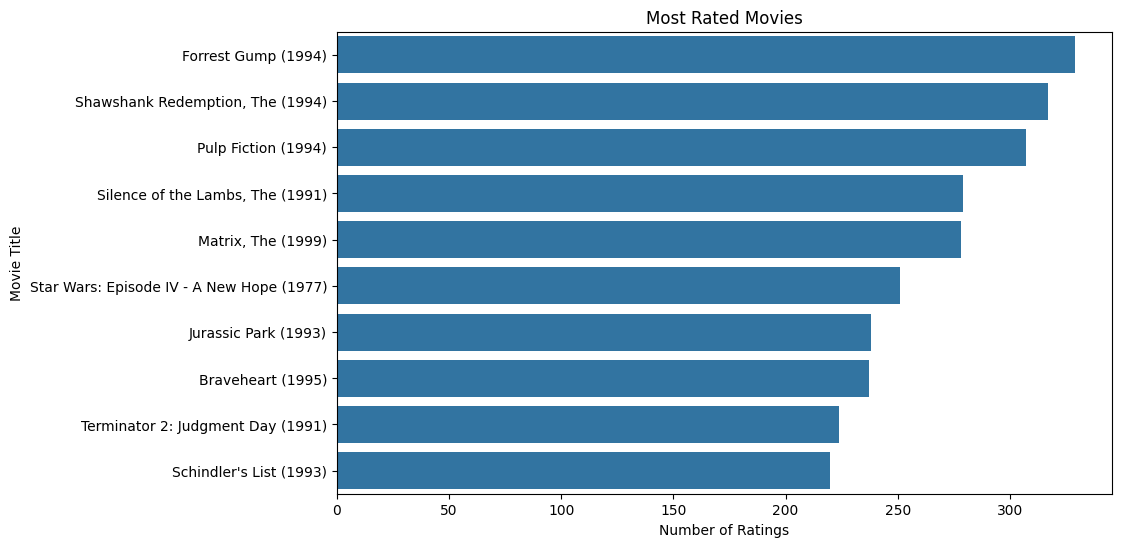

In [58]:
#Visual Representation of the Most Rated Movies

# Top-rated movies
top_movies = data['title'].value_counts().head(10)
plt.figure(figsize=(10, 6))
sns.barplot(x=top_movies.values, y=top_movies.index)
plt.title('Most Rated Movies')
plt.xlabel('Number of Ratings')
plt.ylabel('Movie Title')
plt.show()

# **Data Preprocessing**

In [59]:
# For collaborative filtering, we'll create a user-item matrix.

#Create a user matrix

user_item_matrix = ratings.pivot_table(index='userId', columns='movieId', values='rating').fillna(0)

# Display the user-item matrix
user_movie_ratings.head()

movieId,1,2,3,4,5,6,7,8,9,10,...,193565,193567,193571,193573,193579,193581,193583,193585,193587,193609
userId,,,,,,,,,,,,,,,,,,,,,
1,4.0,0.0,4.0,0.0,0.0,4.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


# **Model Building**

**User-Based Collaborative Filtering using KNN**

In [70]:
# Transpose to get item-user matrix for movie similarity
movie_user_matrix = user_item_matrix.T

#FIt KNN Model

KNN= NearestNeighbors(metric= 'cosine', algorithm= 'brute')

KNN.fit(movie_user_matrix.values)

# Function to get similar movies using KNN
def get_knn_recommendations(movie_title, k=5):
    movie_id = movies[movies['title'] == movie_title]['movieId'].values[0]
    movie_index = list(movie_user_matrix.index).index(movie_id)

    distances, indices = KNN.kneighbors(movie_user_matrix.iloc[movie_index, :].values.reshape(1, -1), n_neighbors=k+1)

    print(f"\nKNN Recommendations for: {movie_title}")
    for i in range(1, len(distances.flatten())):
        idx = indices.flatten()[i]
        similar_movie_id = movie_user_matrix.index[idx]
        similar_title = movies[movies['movieId'] == similar_movie_id]['title'].values[0]
        print(f"{similar_title} (Similarity Score: {1 - distances.flatten()[i]:.2f})")

In [71]:
get_knn_recommendations("Toy Story (1995)", k=5)


KNN Recommendations for: Toy Story (1995)
Toy Story 2 (1999) (Similarity Score: 0.57)
Jurassic Park (1993) (Similarity Score: 0.57)
Independence Day (a.k.a. ID4) (1996) (Similarity Score: 0.56)
Star Wars: Episode IV - A New Hope (1977) (Similarity Score: 0.56)
Forrest Gump (1994) (Similarity Score: 0.55)


**Matrix Factorization using Truncated SVD**

In [72]:
#Apply TruncatedSVD for dimentionality reduction

SVD= TruncatedSVD(n_components= 20, random_state= 42)

matrix_svd= SVD.fit_transform(user_item_matrix.T)

# Compute similarity between movies in latent space
similarity_matrix= cosine_similarity(matrix_svd)

#Map movie ID's to index

movie_id_to_index = {movie_id: idx for idx, movie_id in enumerate(user_item_matrix.columns)}
index_to_movie_id = {idx: movie_id for movie_id, idx in movie_id_to_index.items()}



In [75]:
# Function to get recommendations using Matrix Factorization
def get_svd_recommendations(movie_title, k=5):
    movie_id = movies[movies['title'] == movie_title]['movieId'].values[0]
    movie_idx = movie_id_to_index[movie_id]

    sim_scores = list(enumerate(similarity_matrix[movie_idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)[1:k+1]

    print(f"\nSVD Recommendations for: {movie_title}")
    for idx, score in sim_scores:
        similar_movie_id = index_to_movie_id[idx]
        similar_title = movies[movies['movieId'] == similar_movie_id]['title'].values[0]
        print(f"{similar_title} (Similarity Score: {score:.2f})")


In [76]:
get_svd_recommendations("Toy Story (1995)", k=5)


SVD Recommendations for: Toy Story (1995)
Willy Wonka & the Chocolate Factory (1971) (Similarity Score: 0.91)
Back to the Future (1985) (Similarity Score: 0.88)
Home Alone (1990) (Similarity Score: 0.88)
Star Wars: Episode IV - A New Hope (1977) (Similarity Score: 0.88)
Groundhog Day (1993) (Similarity Score: 0.88)


# **Key Findings, and Insights**

**Key Findings:**




**1.** KNN provides reasonable similarity-based recommendations but can be computationally expensive with large datasets.

**2.** SVD-based dimensionality reduction performed better for scalability and captured deeper latent relationships between movies.

**3.** Genre similarity was implicitly captured through user behavior in collaborative filtering.

**4.** Popular movies like "Toy Story (1995)" returned strong and relevant recommendations in both methods.

**Insights**

**1.** Collaborative filtering (even without user metadata) can effectively suggest movies based on behavioral similarity.

**2.** Dimensionality reduction (SVD) enhances performance by compressing the user-item space while preserving core similarity patterns.

**3.** Cold start problem still exists — new users or new movies with few interactions are difficult to recommend accurately.

**4.** Visualizations helped in understanding rating distributions and movie popularity, providing useful context.

**Author's Details**

**Author:** Ugbovo Yoma

**Email:** ugbovoyoma@gmail.com

**Linkedin:** https://www.linkedin.com/in/ugbovoyoma/